In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

# GridWorld Environment

## Description
A 5×5 deterministic GridWorld.

- **Goal:** (0, 4)
- **Blocked cells:** (2, 1), (2, 3)
- **Step cost:** -1
- **Goal reward:** +10
- **Actions:** ↑ ↓ ← → (Up, Down, Left, Right)

## Grid Layout

```
(0,0) (0,1) (0,2) (0,3)  G
(1,0) (1,1) (1,2) (1,3) (1,4)
(2,0)  X   (2,2)   X   (2,4)
(3,0) (3,1) (3,2) (3,3) (3,4)
(4,0) (4,1) (4,2) (4,3) (4,4)
```

- `G` = Goal (0,4)  
- `X` = Blocked cells  

---

## Action Space

| Action | Symbol | Movement |
|--------|--------|----------|
| Up     | ↑      | (-1, 0)  |
| Down   | ↓      | (1, 0)   |
| Left   | ←      | (0, -1)  |
| Right  | →      | (0, 1)   |

---

## Transition Function
Deterministic transition:

- If state = goal → remain in goal, reward = 0
- If action leads outside grid or into block → remain in same state, reward = -1
- Otherwise move to next state
- If next state = goal → reward = +10
- Else → reward = -1

In [2]:
class GridWorld:
    def __init__(self):
        self.height = 5
        self.width = 5
        self.goal = (0, 4)
        self.initial_state = (4, 0)
        self.blocks = [(2, 1), (2, 3)]
        self.actions = [(-1, 0), (1, 0), (0, -1), (0, 1)] # Up, Down, Left, Right
        self.action_names = ["↑", "↓", "←", "→"]
        self.action_map = dict(zip(self.action_names, self.actions)) # map "↑", "↓", "←", "→" into [(-1, 0), (1, 0), (0, -1), (0, 1)]
        self.step_cost = -1.0
        self.goal_reward = 10.0

    def get_states(self):
        return [ (r,c) for r in range(self.height) for c in range(self.width) ]

    def move(self, state, action):
        next_s = (state[0] + action[0], state[1] + action[1])

        # Boundary & Block Checking
        if (0 <= next_s[0] < self.height and
            0 <= next_s[1] < self.width and
            next_s not in self.blocks):
            return next_s
        else:
            return state


    def transition(self, state, action):
    
        if state == self.goal:
            return [(1.0, 0.0, state)]
    
        # stochastic direction for left & right
        left_map = {
            (-1,0):(0,-1),
            (1,0):(0,1),
            (0,-1):(1,0),
            (0,1):(-1,0)
        }
    
        right_map = {
            (-1,0):(0,1),
            (1,0):(0,-1),
            (0,-1):(-1,0),
            (0,1):(1,0)
        }
    
        actions = [
            (0.8, action),
            (0.1, left_map[action]),
            (0.1, right_map[action])
        ]
    
        results = []
    
        for prob, a in actions:
            next_s = self.move(state, a)
            reward = self.goal_reward if next_s == self.goal else self.step_cost
            results.append((prob, reward, next_s))
    
        return results

# Policy Iteration

## Description
Implements Policy Iteration for a deterministic GridWorld.

- **Discount factor (γ):** 0.9  
- **Convergence threshold (θ):** 0.004  
- **Initial value function:** V(s) = 0  
- **Initial policy:** Always move right (→)

---

## 1. Policy Evaluation

Iteratively updates the value function under current policy π:

V(s) ← r + γ V(s')

Where:
- a = π(s)
- (r, s') = transition(s, a)

Repeat until:
|V_new − V_old| < θ

- Goal state marked as `*`
- Blocked states marked as `■`

---

## 2. Policy Improvement

For each state:

Compute action values:

Q(s, a) = r + γ V(s')

Select best action:

π(s) ← argmax_a Q(s, a)

If any action changes → policy not stable.

---

## 3. Solve Procedure

Repeat:
1. Policy Evaluation  
2. Policy Improvement  

Until policy becomes stable.

---


In [3]:
class PolicyIteration:
    def __init__ (self, env):
        self.env = env
        self.gamma = 0.9
        self.V = np.zeros((env.height , env.width))
        # Converge threshold
        self.theta = 0.004
        # Initial policy - all direction to the right
        self.policy = np.full((self.env.height, self.env.width), '→', dtype=object)

    def policy_eval(self):
        while True:
            delta = 0
            # Loop through all states
            for s in self.env.get_states():
                # Skip if state is terminal or block
                if s == self.env.goal:
                    # For visualization purposes
                    self.policy[s] = '*'
                    continue    
                elif s in self.env.blocks:
                    # For visualization purposes
                    self.policy[s] = '■'
                    continue

                v_old = self.V[s]

                # Get action from policy π
                a = self.env.action_map[self.policy[s]]

                transitions = self.env.transition(s, a)

                # Get reward and next state after taking action a under policy π
                new_v = 0
                for prob, reward, next_s in transitions:
                    # Calculate expected value function for taking policy π
                    new_v += prob * (reward + self.gamma * self.V[next_s])
    
                self.V[s] = new_v
    
                delta = max(delta, abs(v_old - new_v))
    
            if delta < self.theta:
                break
    
    def policy_improv(self):
        policy_stable = True

        # Loop through all states
        for s in self.env.get_states():
            if s == self.env.goal or s in self.env.blocks:
                continue

            # Store Q value (up, down, left ,right) for state s
            q_value = []
            # Store old action
            old_action = self.policy[s]

            # Calculate Q value for all 4 actions
            for a in self.env.actions:
                # Get reward and next state after taking action a in state s
                transitions = self.env.transition(s, a)

                # Stochastic action value
                action_value = 0
                for prob, reward, next_s in transitions:
                    action_value += prob * (reward + self.gamma * self.V[next_s])

                # Store action value 
                q_value.append(action_value)

            # Convert highest action value to "↑", "↓", "←", "→"
            best_action_idx = np.argmax(q_value)
            
            # Update policy
            self.policy[s] = self.env.action_names[best_action_idx]

            # Check if action changed
            if old_action != self.policy[s]:
                policy_stable = False

        return policy_stable

    def solve(self):
        while True:
            self.policy_eval()
            policy_stable = self.policy_improv()
            if policy_stable:
                break

# Value Iteration

## Description
Implements Value Iteration for a deterministic GridWorld.

- **Discount factor (γ):** 0.9  
- **Convergence threshold (θ):** 0.004  
- **Initial value function:** V(s) = 0  
- **Policy representation:** ↑ ↓ ← →

---

## Value Update (Bellman Optimality)

For each state:

V(s) ← maxₐ [ r + γ V(s') ]

Where:
- (r, s') = transition(s, a)
- Deterministic transitions

- Goal state marked as `*`
- Blocked states marked as `■`

---

## Algorithm Steps

Repeat for fixed iterations (or until convergence):

1. For each non-terminal, non-block state:
   - Compute Q(s, a) for all actions
   - Update V(s) with maximum action value
   - Update policy with argmax action

2. Replace old V with updated values

---


In [ ]:
class ValueIteration:
    def __init__ (self, env):
        self.env = env
        self.gamma = 0.9
        self.V = np.zeros((env.height , env.width))
        # Converge threshold
        self.theta = 0.004
        self.policy = np.full((self.env.height, self.env.width), ' ', dtype=object)

    def solve(self):
        while True:
            delta = 0
            v_new = self.V.copy()

            # Loop through all states
            for s in self.env.get_states():
                # Skip if state is terminal or block
                if s == self.env.goal: 
                    self.policy[s] = '*'
                    continue    
                elif s in self.env.blocks:
                    self.policy[s] = '■'
                    continue

                q_value = []
                v_old = self.V[s]

                for a in self.env.actions:
                    # calculate Q value for action a
                    # Get reward and next state after taking action a in state s
                    transitions = self.env.transition(s, a)

                    action_value = 0
                    for prob, reward, next_s in transitions:
                        action_value += prob * (reward + self.gamma * self.V[next_s])
                    q_value.append(action_value)

                # Best action value
                best_value = max(q_value)
                v_new[s] = best_value

                delta = max(delta, abs(v_old - best_value))

                best_action_idx = np.argmax(q_value)
                self.policy[s] = self.env.action_names[best_action_idx]

            self.V = v_new
            if delta < self.theta:
                break

In [5]:
def plot_policies(main_title, *policies):

    num_plots = len(policies)
    fig, axes = plt.subplots(1, num_plots, figsize=(6 * num_plots, 6))

    # If only one subplot, make it iterable
    if num_plots == 1:
        axes = [axes]

    for ax, (policy, title) in zip(axes, policies):
        rows, cols = policy.shape

        # Grid setup
        ax.set_xticks(range(cols + 1))
        ax.set_yticks(range(rows + 1))
        ax.grid(True, color='black', linewidth=1.5)

        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.set_title(title, fontsize=14, pad=10)

        for r in range(rows):
            for c in range(cols):
                symbol = policy[r, c]
                color = 'red' if symbol in ['*', '■'] else 'blue'

                ax.text(
                    c + 0.5,
                    rows - r - 0.5,
                    symbol,
                    va='center',
                    ha='center',
                    fontsize=22,
                    fontweight='bold',
                    color=color
                )

        ax.set_xlim(0, cols)
        ax.set_ylim(0, rows)

    plt.suptitle(main_title, fontsize=18)
    plt.tight_layout()
    plt.show()

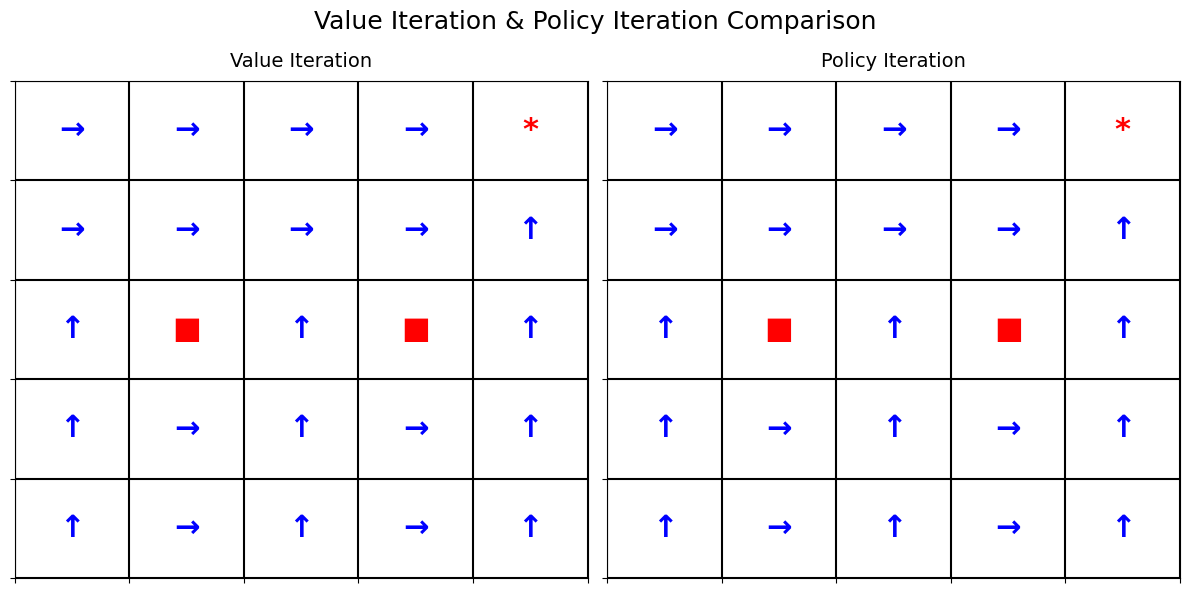

In [6]:
env = GridWorld()
vi_agent = ValueIteration(env)
pi_agent = PolicyIteration(env)

vi_agent.solve()
pi_agent.solve()

plot_policies(
    "Value Iteration & Policy Iteration Comparison",
    (vi_agent.policy, "Value Iteration"),
    (pi_agent.policy, "Policy Iteration"),)

# print(vi_agent.policy)
# print(pi_agent.policy)

In [ ]:
class monte_carlo:
    def __init__(self, env ,ep):
        self.env = env
        self.epsilon = 0.1
        self.episodes = ep 
        self.gamma = 0.9

        self.V = np.zeros((env.height , env.width))

        self.returns = {}
        self.Q = {}

        for s in env.get_states():
            for a in env.actions:
                self.Q[ ( s, a ) ] = 0
                self.returns[ ( s, a ) ] = []

        self.policy = np.full((self.env.height, self.env.width), ' ', dtype=object)

    def epsilon_greedy (self, state):
        # Explore randomly
        if random.random() < self.epsilon:
            return random.choice(self.env.actions)
        # Explore highest Q value at current state
        else:
            q_values = [self.Q[(state, a)] for a in self.env.actions]
            max_q = max(q_values)
        
            # Find all indices that have the max value
            max_actions = [a for a, q in zip(self.env.actions, q_values) if q == max_q]
        
            return random.choice(max_actions)

    def generate_episode(self):
        episode = []
        state = (4, 0)
        
        while state != self.env.goal:
            action = self.epsilon_greedy(state)
            transitions = self.env.transition(state, action)

            probs = [t[0] for t in transitions]
            idx = np.random.choice(len(transitions), p=probs)
    
            prob, reward, next_s = transitions[idx]
    
            episode.append((state, action, reward))

            state = next_s

        return episode

    def first_visit(self):
        count = 0
        for _ in range(self.episodes):
            G = 0
            # Set to track visited states
            visited = set()

            # Generate an episode (state, action, reward)
            policy = self.generate_episode()

            # Loop backwards
            for i in reversed(range(len(policy))):
                state, action, reward = policy[i]
                G = self.gamma * G + reward

                if ( state, action ) not in visited:
                    visited.add(( state, action ))

                    self.returns[( state, action )].append(G)
                    self.Q[( state, action )] = np.mean(self.returns[( state, action )])

    def extract_policy(self):
        for state in self.env.get_states():

            if state == self.env.goal: 
                    self.policy[state] = '*'
                    continue    
            elif state in self.env.blocks:
                self.policy[state] = '■'
                continue

            q_values = [self.Q[(state, a)] for a in self.env.actions]
            best_action = np.argmax(q_values)
            self.policy[state] = self.env.action_names[best_action]

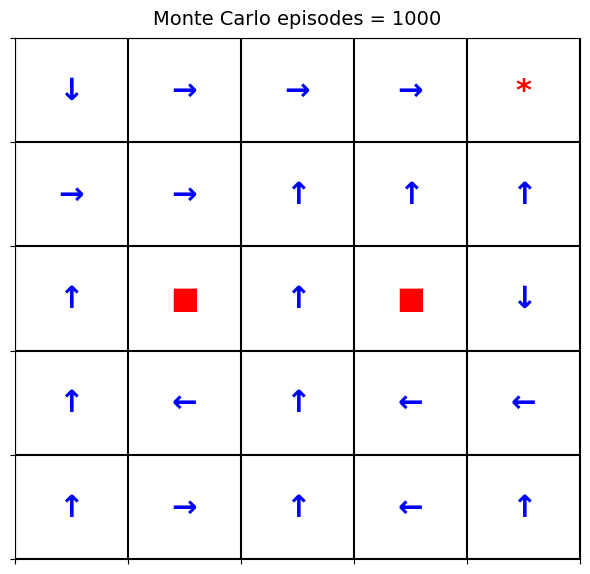

In [8]:
env = GridWorld()
mc = monte_carlo(env, 1000)

mc.first_visit()
mc.extract_policy()
plot_policies(
    "",
    (mc.policy,"Monte Carlo episodes = 1000")
)

In [9]:
env = GridWorld()
mc = monte_carlo(env, 10000)

mc.first_visit()
mc.extract_policy()
plot_policies(
    "",
    (mc.policy,"Monte Carlo episodes = 10000")
)

KeyboardInterrupt: 

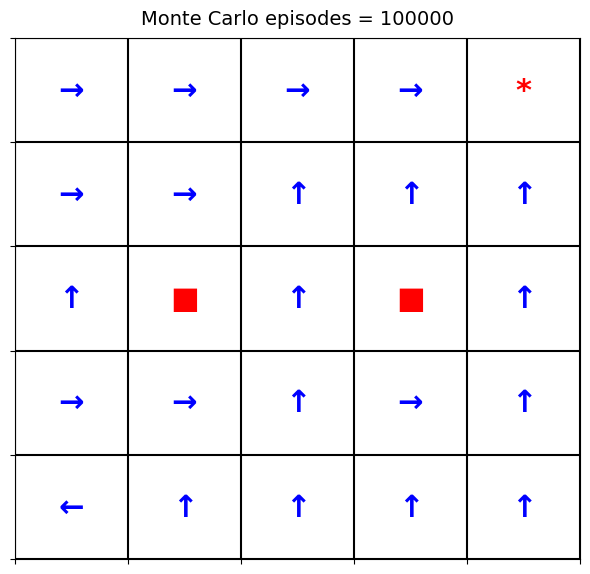

In [ ]:
env = GridWorld()
mc = monte_carlo(env, 100000)

mc.first_visit()
mc.extract_policy()
plot_policies(
    "",
    (mc.policy,"Monte Carlo episodes = 100000")
)

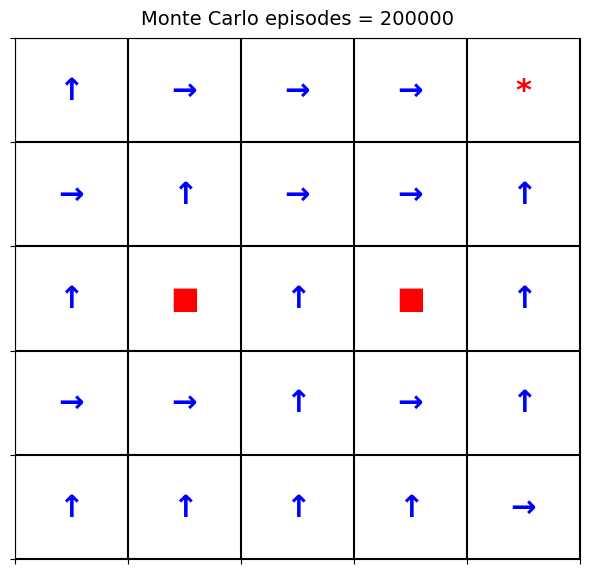

In [ ]:
env = GridWorld()
mc = monte_carlo(env, 200000)

mc.first_visit()
mc.extract_policy()
plot_policies(
    "",
    (mc.policy,"Monte Carlo episodes = 200000")
)

In [ ]:
env = GridWorld()
mc = monte_carlo(env, 500000)

mc.first_visit()
mc.extract_policy()
plot_policies(
    "",
    (mc.policy,"Monte Carlo episodes = 500000")
)

In [ ]:
class Q_learning:
    def __init__ (self, env):
        self.Q = np.zeros((env.height , env.width, 4))
        self.env = env
        self.alpha = 0.1
        self.gamma = 0.9
        self.epsilon = 0.1
        self.episodes = 600000
        
        self.policy = np.full((self.env.height, self.env.width), ' ', dtype=object)

    def epsilon_greedy (self, state):
        # Explore randomly
        if np.random.random() < self.epsilon:
            return np.random.randint(len(self.env.actions))
        # Explore highest Q value at current state
        else:
            q_values = self.Q[state[0], state[1], :]
            max_q = np.max(q_values)
        
            # Find all indices that have the max value
            max_actions = np.where(q_values == max_q)[0]
        
            # Randomly choose among them
            return np.random.choice(max_actions)

    def solve(self):
        for episode in range(self.episodes):
            state = self.env.initial_state

            while state != self.env.goal:
                # Choose an epsilon greedy action
                action_idx = self.epsilon_greedy(state)
                action = self.env.actions[action_idx]
                
                transitions = self.env.transition(state, action)

                probs = [t[0] for t in transitions]
                idx = np.random.choice(len(transitions), p=probs)
                
                prob, reward, next_s = transitions[idx]

                # Update Q value
                next_q = np.max(self.Q[next_s[0], next_s[1], :])

                td_target = reward + self.gamma * next_q
                self.Q[state[0], state[1], action_idx] += self.alpha * (td_target - self.Q[state[0], state[1], action_idx])

                state = next_s

    def extract_policy(self):
        for r in range(self.env.height):
            for c in range(self.env.width):
    
                state = (r, c)
    
                if state == self.env.goal:
                    self.policy[r, c] = '*'
                    continue
                elif state in self.env.blocks:
                    self.policy[r, c] = '■'
                    continue
    
                best_action_idx = np.argmax(self.Q[r, c])
                self.policy[r, c] = self.env.action_names[best_action_idx]

In [ ]:
env = GridWorld()
t = Q_learning(env)
t.solve()
t.extract_policy()
print(t.policy)

In [ ]:
plot_policies(
    [vi_agent.policy, pi_agent.policy, t.policy, mc.policy],
    ["Value Iteration", "Policy Iteration", "Q-Learning", "Policy 4"]
)

In [ ]:
plot_policies(
    "GridWorld RL Comparison",
    (vi_agent.policy, "Value Iteration"),
    (pi_agent.policy, "Policy Iteration"),
    (t.policy, "Q-Learning"),
    (mc.policy, "Monte Carlo")
)

